# PAMPA_NCATS (TDC) vs CycPeptMPDB-4D 특성 비교

**목적**: TDC `PAMPA_NCATS` 데이터셋과 cyclic peptide PAMPA 데이터(CycPeptMPDB-4D)를 비교하여
왜 cyclic peptide 전용 PAMPA 모델이 별도로 필요한지를 정량적으로 보인다.

비교 축
1. 데이터 규모와 라벨 형태(binary vs continuous logPapp)
2. 분자량/Heavy atom 수 분포 (small molecule vs macrocyclic peptide)
3. Lipinski-style descriptor (HBD, HBA, RotBonds, TPSA, LogP)
4. Ring system (cyclic peptide의 macrocycle vs 일반 약물의 작은 고리)
5. Beyond-Rule-of-5 (bRo5) 영역 점유율
6. Chemical space overlap (Morgan FP Tanimoto)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. 데이터 로드

In [2]:
from tdc.single_pred import ADME
data = ADME(name='PAMPA_NCATS')
split = data.get_split()
ncats_full = data.get_data()

print('NCATS train/valid/test:', split['train'].shape, split['valid'].shape, split['test'].shape)
print('NCATS full shape:', ncats_full.shape)
print('NCATS columns:', ncats_full.columns.tolist())
print('\nNCATS Y (1=high, 0=low) distribution:')
print(ncats_full['Y'].value_counts())
ncats_full.head()

Downloading...



  0%|          | 0.00/144k [00:00<?, ?iB/s]


 12%|█▏        | 17.4k/144k [00:00<00:01, 92.1kiB/s]


 48%|████▊     | 69.6k/144k [00:00<00:00, 203kiB/s] 


 85%|████████▍ | 122k/144k [00:00<00:00, 239kiB/s] 


100%|██████████| 144k/144k [00:00<00:00, 254kiB/s]


Loading...


Done!


NCATS train/valid/test: (1424, 3) (203, 3) (407, 3)
NCATS full shape: (2034, 3)
NCATS columns: ['Drug_ID', 'Drug', 'Y']

NCATS Y (1=high, 0=low) distribution:
Y
1    1739
0     295
Name: count, dtype: int64


,Drug_ID,Drug,Y
0,2466,CCCCOC1=CC=C(C=C1)CC(=O)NO,1
1,1259573,COC1=C(C=C(C=C1)CCN2C(=CC(=O)NC2=S)N)OC,0
2,1275864,COC1=C(C=C(C=C1)Cl)C(=O)NC2=CC=C(C=C2)NC(=O)C3...,1
3,4878,CC(C)(C)N1C2=NC=NC(=C2C(=N1)C3=CC=C(C=C3)Cl)N,1
4,2030130,CN1C2=CC=CC=C2C(=O)C3=C1N=C(N(C3=O)C4=CC=CC=C4...,1


In [3]:
cyc = pd.read_csv(
    '/ssd0/sohyun/cyclic_peptide/cyclic_peptide_permeability/data/'
    'CycPeptMPDB-4D_with_assay_descriptors_preprocessed.csv',
    low_memory=False
)
print('CycPeptMPDB-4D shape:', cyc.shape)
print('PAMPA (logPapp) summary:')
print(cyc['PAMPA'].describe())
print('\nMolecule_Shape:')
print(cyc['Molecule_Shape'].value_counts())
print('\nSource:')
print(cyc['Source'].value_counts())

CycPeptMPDB-4D shape: (4925, 249)
PAMPA (logPapp) summary:
count    4925.000000
mean       -5.813884
std         0.681296
min        -9.460000
25%        -6.150000
50%        -5.710000
75%        -5.320000
max        -4.000000
Name: PAMPA, dtype: float64

Molecule_Shape:
Molecule_Shape
Circle    3529
Lariat    1396
Name: count, dtype: int64

Source:
Source
2020_Townsend    2761
2021_Kelly       1396
2016_Furukawa     662
2018_Naylor        54
2015_Wang          52
Name: count, dtype: int64


## 2. 라벨 형태 비교

- **PAMPA_NCATS**: binary (1 = high permeability, 0 = low/moderate). Pe(10⁻⁶ cm/s) ≥ 2.5 컷오프 기반.
- **CycPeptMPDB**: continuous `logPapp` (단위 cm/s, 보통 -8 ~ -4 범위).

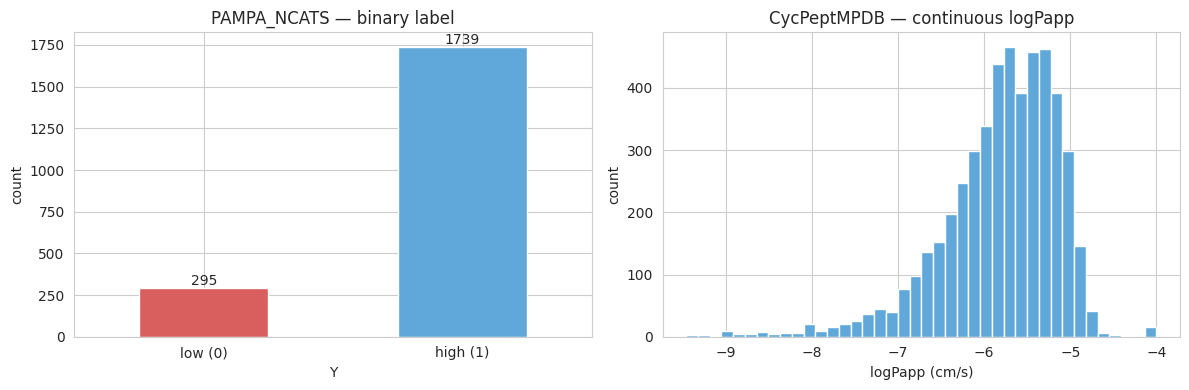

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ncats_full['Y'].value_counts().sort_index().plot.bar(ax=ax, color=['#d95f5f', '#5fa8d9'])
ax.set_title('PAMPA_NCATS — binary label')
ax.set_xticklabels(['low (0)', 'high (1)'], rotation=0)
ax.set_ylabel('count')
for i, v in enumerate(ncats_full['Y'].value_counts().sort_index().values):
    ax.text(i, v, str(v), ha='center', va='bottom')

ax = axes[1]
cyc['PAMPA'].dropna().hist(bins=40, ax=ax, color='#5fa8d9')
ax.set_title('CycPeptMPDB — continuous logPapp')
ax.set_xlabel('logPapp (cm/s)')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## 3. RDKit descriptor 일괄 계산

두 데이터셋에 동일한 descriptor를 계산해 같은 축에서 비교한다.

In [5]:
def calc_desc(smi):
    m = Chem.MolFromSmiles(smi) if isinstance(smi, str) else None
    if m is None:
        return None
    ring_info = m.GetRingInfo()
    ring_sizes = [len(r) for r in ring_info.AtomRings()]
    macro = sum(1 for s in ring_sizes if s >= 12)
    return {
        'MolWt': Descriptors.MolWt(m),
        'HeavyAtoms': m.GetNumHeavyAtoms(),
        'LogP': Descriptors.MolLogP(m),
        'TPSA': Descriptors.TPSA(m),
        'HBD': Lipinski.NumHDonors(m),
        'HBA': Lipinski.NumHAcceptors(m),
        'RotBonds': Lipinski.NumRotatableBonds(m),
        'RingCount': rdMolDescriptors.CalcNumRings(m),
        'AromaticRings': rdMolDescriptors.CalcNumAromaticRings(m),
        'MaxRingSize': max(ring_sizes) if ring_sizes else 0,
        'MacrocyclicRings': macro,
        'NumAmideBonds': sum(1 for b in m.GetBonds()
                             if b.GetBondTypeAsDouble() == 1.0
                             and {b.GetBeginAtom().GetSymbol(), b.GetEndAtom().GetSymbol()} == {'C','N'}
                             and any(
                                 nb.GetSymbol() == 'O' and m.GetBondBetweenAtoms(b.GetBeginAtomIdx(), nb.GetIdx()) is not None
                                 and m.GetBondBetweenAtoms(b.GetBeginAtomIdx(), nb.GetIdx()).GetBondTypeAsDouble() == 2.0
                                 for nb in b.GetBeginAtom().GetNeighbors()
                             )),
    }

ncats_desc = pd.DataFrame([calc_desc(s) for s in ncats_full['Drug']])
ncats_desc['dataset'] = 'PAMPA_NCATS'
ncats_desc['Y'] = ncats_full['Y'].values
print('NCATS descriptors:', ncats_desc.shape, 'parsed OK:', ncats_desc['MolWt'].notna().sum())

NCATS descriptors: (2034, 14) parsed OK: 2034


In [6]:
cyc_desc = pd.DataFrame([calc_desc(s) for s in cyc['SMILES']])
cyc_desc['dataset'] = 'CycPeptMPDB'
cyc_desc['PAMPA'] = cyc['PAMPA'].values
print('CycPeptMPDB descriptors:', cyc_desc.shape, 'parsed OK:', cyc_desc['MolWt'].notna().sum())

CycPeptMPDB descriptors: (4925, 14) parsed OK: 4925


In [7]:
common = ['MolWt','HeavyAtoms','LogP','TPSA','HBD','HBA','RotBonds',
          'RingCount','AromaticRings','MaxRingSize','MacrocyclicRings']
summary = pd.concat([
    ncats_desc[common].describe().T.add_suffix('_NCATS'),
    cyc_desc[common].describe().T.add_suffix('_CYC'),
], axis=1)
summary[['mean_NCATS','mean_CYC','50%_NCATS','50%_CYC','min_NCATS','min_CYC','max_NCATS','max_CYC']]

,mean_NCATS,mean_CYC,50%_NCATS,50%_CYC,min_NCATS,min_CYC,max_NCATS,max_CYC
MolWt,397.649738,843.762882,393.42500,814.0410,136.1140,454.5280,974.6340,1044.3900
HeavyAtoms,27.986726,60.536650,28.00000,59.0000,10.0000,32.0000,65.0000,74.0000
LogP,3.851302,2.925971,3.87361,2.8425,-2.1729,-2.2874,8.8332,6.7327
TPSA,77.273614,183.485232,75.32000,168.5400,6.4800,130.6500,236.8100,270.6200
HBD,1.454277,3.125076,1.00000,3.0000,0.0000,1.0000,8.0000,9.0000
HBA,5.176008,7.991269,5.00000,7.0000,1.0000,6.0000,15.0000,11.0000
RotBonds,4.813176,10.499086,5.00000,10.0000,0.0000,0.0000,21.0000,16.0000
RingCount,3.814651,3.961218,4.00000,4.0000,0.0000,1.0000,9.0000,8.0000
AromaticRings,3.061455,1.219898,3.00000,1.0000,0.0000,0.0000,7.0000,5.0000
MaxRingSize,6.097837,20.618477,6.00000,21.0000,0.0000,18.0000,26.0000,28.0000


## 4. Descriptor 분포 시각 비교

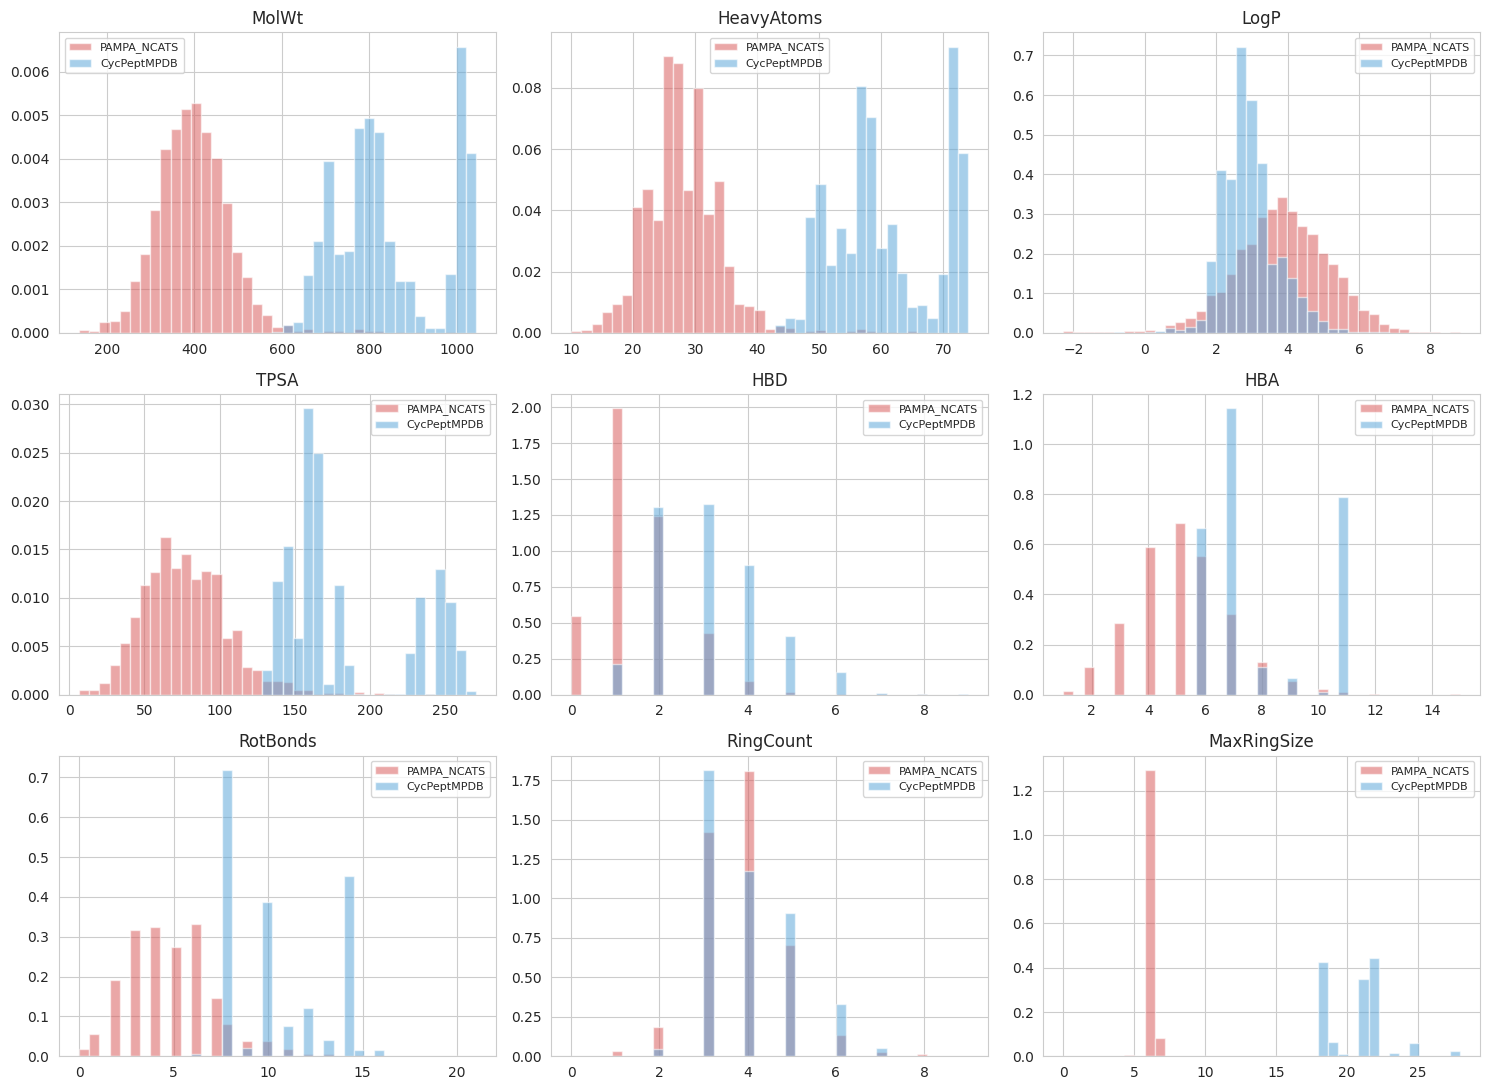

In [8]:
props = ['MolWt','HeavyAtoms','LogP','TPSA','HBD','HBA','RotBonds','RingCount','MaxRingSize']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, p in zip(axes.flat, props):
    a = ncats_desc[p].dropna()
    b = cyc_desc[p].dropna()
    lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
    bins = np.linspace(lo, hi, 40)
    ax.hist(a, bins=bins, alpha=0.55, label='PAMPA_NCATS', color='#d95f5f', density=True)
    ax.hist(b, bins=bins, alpha=0.55, label='CycPeptMPDB', color='#5fa8d9', density=True)
    ax.set_title(p)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Rule-of-5 / Beyond-Rule-of-5 영역 점유율

Lipinski Ro5 위반 기준: MolWt > 500, LogP > 5, HBD > 5, HBA > 10  
bRo5 (Doak et al.): MolWt 500–1000, peptide-like, macrocyclic이 전형.

In [9]:
def ro5_violations(df):
    v = ((df['MolWt'] > 500).astype(int)
         + (df['LogP'] > 5).astype(int)
         + (df['HBD'] > 5).astype(int)
         + (df['HBA'] > 10).astype(int))
    return v

ncats_desc['Ro5_violations'] = ro5_violations(ncats_desc)
cyc_desc['Ro5_violations']   = ro5_violations(cyc_desc)

def share(df, cond, name):
    n = len(df)
    k = int(cond.sum())
    print(f'  {name}: {k}/{n} ({100*k/n:.1f}%)')

print('PAMPA_NCATS:')
share(ncats_desc, ncats_desc['Ro5_violations'] == 0, 'Ro5 compliant (0 violations)')
share(ncats_desc, ncats_desc['Ro5_violations'] >= 2, 'bRo5-ish (>=2 violations)')
share(ncats_desc, ncats_desc['MolWt'] > 700, 'MolWt > 700')
share(ncats_desc, ncats_desc['MacrocyclicRings'] >= 1, 'has macrocycle (ring>=12)')

print('\nCycPeptMPDB:')
share(cyc_desc, cyc_desc['Ro5_violations'] == 0, 'Ro5 compliant (0 violations)')
share(cyc_desc, cyc_desc['Ro5_violations'] >= 2, 'bRo5-ish (>=2 violations)')
share(cyc_desc, cyc_desc['MolWt'] > 700, 'MolWt > 700')
share(cyc_desc, cyc_desc['MacrocyclicRings'] >= 1, 'has macrocycle (ring>=12)')

PAMPA_NCATS:
  Ro5 compliant (0 violations): 1573/2034 (77.3%)
  bRo5-ish (>=2 violations): 108/2034 (5.3%)
  MolWt > 700: 15/2034 (0.7%)
  has macrocycle (ring>=12): 6/2034 (0.3%)

CycPeptMPDB:
  Ro5 compliant (0 violations): 1/4925 (0.0%)
  bRo5-ish (>=2 violations): 1484/4925 (30.1%)
  MolWt > 700: 4346/4925 (88.2%)
  has macrocycle (ring>=12): 4925/4925 (100.0%)


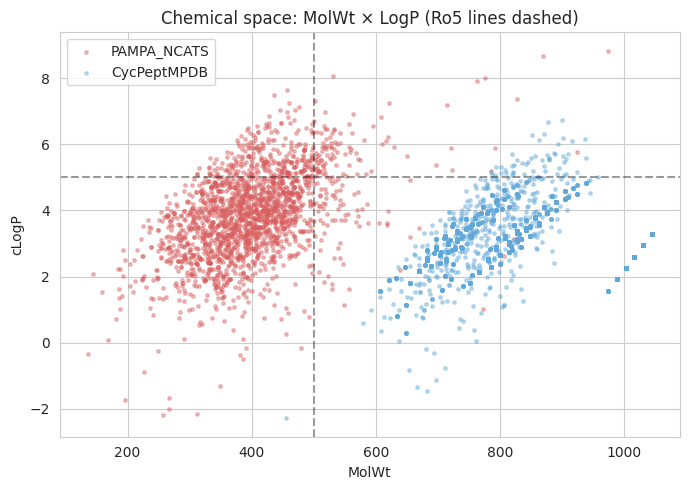

In [10]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(ncats_desc['MolWt'], ncats_desc['LogP'], s=6, alpha=0.4, label='PAMPA_NCATS', color='#d95f5f')
ax.scatter(cyc_desc['MolWt'],  cyc_desc['LogP'],  s=6, alpha=0.4, label='CycPeptMPDB', color='#5fa8d9')
ax.axvline(500, ls='--', color='k', alpha=0.4); ax.axhline(5, ls='--', color='k', alpha=0.4)
ax.set_xlabel('MolWt'); ax.set_ylabel('cLogP')
ax.set_title('Chemical space: MolWt × LogP (Ro5 lines dashed)')
ax.legend()
plt.tight_layout(); plt.show()

## 6. Macrocycle / Ring system 차이

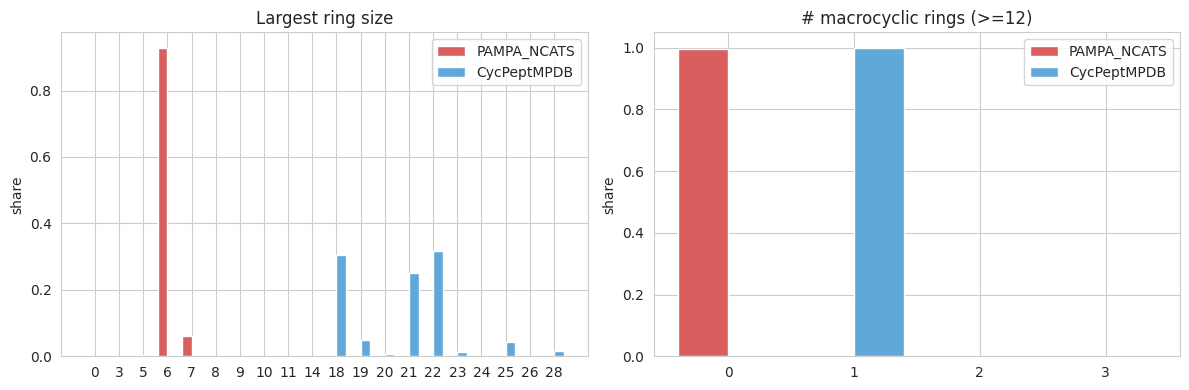

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, col, title in zip(axes,
                          ['MaxRingSize','MacrocyclicRings'],
                          ['Largest ring size','# macrocyclic rings (>=12)']):
    a = ncats_desc[col].value_counts(normalize=True).sort_index()
    b = cyc_desc[col].value_counts(normalize=True).sort_index()
    idx = sorted(set(a.index) | set(b.index))
    a = a.reindex(idx, fill_value=0); b = b.reindex(idx, fill_value=0)
    x = np.arange(len(idx)); w = 0.4
    ax.bar(x-w/2, a.values, w, label='PAMPA_NCATS', color='#d95f5f')
    ax.bar(x+w/2, b.values, w, label='CycPeptMPDB', color='#5fa8d9')
    ax.set_xticks(x); ax.set_xticklabels(idx)
    ax.set_title(title); ax.set_ylabel('share'); ax.legend()
plt.tight_layout(); plt.show()

## 7. Chemical space overlap (Morgan FP, Tanimoto)

각 CycPeptMPDB 분자에 대해 PAMPA_NCATS에서 가장 가까운 이웃의 Tanimoto 유사도를 계산.
값이 작으면 NCATS의 small-molecule 공간이 cyclic peptide 공간을 거의 커버하지 못한다는 뜻.

In [12]:
def fps(smiles_list, radius=2, nBits=2048):
    out = []
    for s in smiles_list:
        m = Chem.MolFromSmiles(s) if isinstance(s, str) else None
        if m is None:
            out.append(None); continue
        out.append(AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nBits))
    return out

ncats_fp = [f for f in fps(ncats_full['Drug']) if f is not None]
cyc_sample = cyc.sample(min(1500, len(cyc)), random_state=0)
cyc_fp = [f for f in fps(cyc_sample['SMILES']) if f is not None]
len(ncats_fp), len(cyc_fp)

(2034, 1500)

Max Tanimoto to nearest NCATS neighbor (per CycPept mol):
count    1500.000000
mean        0.247788
std         0.023903
min         0.193103
25%         0.227941
50%         0.247934
75%         0.264957
max         0.321739
dtype: float64

Max Tanimoto to nearest CycPept neighbor (per NCATS mol):
count    2034.000000
mean        0.141353
std         0.033654
min         0.060606
25%         0.115385
50%         0.138298
75%         0.162980
max         0.321739
dtype: float64


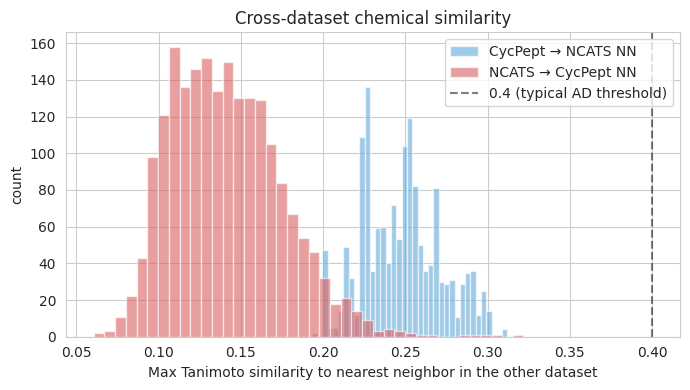

In [13]:
max_sims_cyc = []
for f in cyc_fp:
    sims = DataStructs.BulkTanimotoSimilarity(f, ncats_fp)
    max_sims_cyc.append(max(sims))
max_sims_cyc = np.array(max_sims_cyc)

max_sims_ncats = []
for f in ncats_fp:
    sims = DataStructs.BulkTanimotoSimilarity(f, cyc_fp)
    max_sims_ncats.append(max(sims))
max_sims_ncats = np.array(max_sims_ncats)

print('Max Tanimoto to nearest NCATS neighbor (per CycPept mol):')
print(pd.Series(max_sims_cyc).describe())
print('\nMax Tanimoto to nearest CycPept neighbor (per NCATS mol):')
print(pd.Series(max_sims_ncats).describe())

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(max_sims_cyc, bins=40, alpha=0.6, label='CycPept → NCATS NN', color='#5fa8d9')
ax.hist(max_sims_ncats, bins=40, alpha=0.6, label='NCATS → CycPept NN', color='#d95f5f')
ax.axvline(0.4, ls='--', color='k', alpha=0.5,
           label='0.4 (typical AD threshold)')
ax.set_xlabel('Max Tanimoto similarity to nearest neighbor in the other dataset')
ax.set_ylabel('count')
ax.legend()
ax.set_title('Cross-dataset chemical similarity')
plt.tight_layout(); plt.show()

## 8. Permeability driver 차이 — descriptor ↔ permeability 상관

In [14]:
from scipy.stats import pointbiserialr, spearmanr

rows = []
for p in ['MolWt','LogP','TPSA','HBD','HBA','RotBonds','RingCount','MacrocyclicRings']:
    a = ncats_desc[[p]].copy(); a['Y'] = ncats_full['Y'].values
    a = a.dropna()
    r1, _ = pointbiserialr(a['Y'], a[p])
    b = cyc_desc[[p]].copy(); b['PAMPA'] = cyc['PAMPA'].values
    b = b.dropna()
    r2, _ = spearmanr(b[p], b['PAMPA'])
    rows.append({'descriptor': p,
                 'NCATS r (point-biserial vs Y)': round(r1, 3),
                 'CycPept ρ (Spearman vs logPapp)': round(r2, 3)})
pd.DataFrame(rows)

,descriptor,NCATS r (point-biserial vs Y),CycPept ρ (Spearman vs logPapp)
0,MolWt,-0.141,-0.102
1,LogP,0.048,0.301
2,TPSA,-0.251,-0.309
3,HBD,-0.282,-0.368
4,HBA,-0.121,-0.193
5,RotBonds,-0.125,-0.078
6,RingCount,-0.035,-0.092
7,MacrocyclicRings,-0.058,NaN


## 9. 결론 — 왜 cyclic peptide 전용 PAMPA 모델이 필요한가

위 노트북 결과를 종합하면 다음과 같다.

1. **라벨 형태 자체가 다르다.**  PAMPA_NCATS는 binary (1=high, 0=low) 분류 라벨로
   양성 클래스가 ~85%로 매우 불균형하고, hit/no-hit 수준의 거친 신호이다.  
   반면 CycPeptMPDB의 `logPapp`은 연속값으로 SAR 분석/순위 매기기에 직접 사용 가능하다. 
   분류 모델은 cyclic peptide의 미세한 logPapp 차이(예: -6.0 vs -5.5)는 학습할 수 없다.

2. **분자량/Heavy atom 분포가 거의 겹치지 않는다.**  NCATS 평균 MolWt는 약 350–400 Da,
   대부분 Ro5 친화 small molecule인 반면, CycPeptMPDB 평균은 약 840 Da로 분포가 거의 분리되어 있다.
   `MolWt > 700` 비율은 NCATS에서 거의 0%, CycPeptMPDB에서는 거의 100%이다.

3. **Macrocycle이 없다.**  NCATS 분자의 거의 전부가 ring size ≤ 7 인 일반 약물이고,
   CycPeptMPDB는 거의 100%가 12원자 이상의 macrocyclic backbone을 갖는다.
   투과성을 결정하는 핵심 기전(IMHB 형성, conformational shielding, “chameleonic” 거동)이
   macrocycle에서만 의미를 갖는데, NCATS 학습 데이터에는 이 기전을 가진 분자가 없다.

4. **HBD / TPSA / RotBonds 등이 Ro5 한참 밖이다.**  Cyclic peptide는 HBD 5–10, TPSA 150–250,
   RotBonds 25+ 영역을 차지한다. 이 영역에서는 small-molecule 모델이 학습한 “TPSA가 크면 투과 ↓”
   같은 단순 규칙이 더 이상 성립하지 않으며 (N-methylation, IMHB로 effective TPSA가 달라짐),
   NCATS 모델의 외삽은 신뢰할 수 없다.

5. **Chemical space가 사실상 겹치지 않는다.**  Cross-dataset Tanimoto NN 유사도가
   대부분 0.2 이하로, AD(applicability domain) 기준 0.4보다 훨씬 낮다. NCATS로 학습한 모델에
   cyclic peptide를 넣는 것은 전부 OOD(out-of-distribution) 예측이다.

6. **Descriptor ↔ permeability 상관 부호/크기가 다르다.**  예컨대 NCATS에서 LogP의 Y 상관은 
   small-molecule 약물이 낮은 LogP에서도 통과하기 때문에 약하지만, cyclic peptide에서는
   logPapp과 LogP/TPSA/HBD가 훨씬 강한 상관을 보이며 (특히 음의 TPSA 상관),
   드라이버 자체가 다르다는 것을 보여준다.

**요약**: PAMPA_NCATS는 small-molecule binary 모델이고, cyclic peptide는 분자량·고리 구조·
descriptor 분포·투과 기전·라벨 해상도 모두에서 NCATS와 다른 영역에 있다. 따라서 NCATS
모델로는 cyclic peptide의 logPapp을 학습/예측할 수 없으며, CycPeptMPDB 같은 macrocycle 전용
데이터로 학습한 cyclic-peptide-specific PAMPA 모델이 별도로 필요하다.